In [24]:
import pandas as pd
import numpy as np
import seaborn as sns


In [27]:
df = pd.read_csv('wine_data.csv',usecols=[0,1,2])
df.columns=['ClassLabel','Alcohol','MalicAcid'] 
df.sample(4)

,ClassLabel,Alcohol,MalicAcid
72,2,12.99,1.67
81,2,12.08,1.13
169,3,12.20,3.03
154,3,13.17,5.19


<Axes: xlabel='Alcohol', ylabel='Density'>

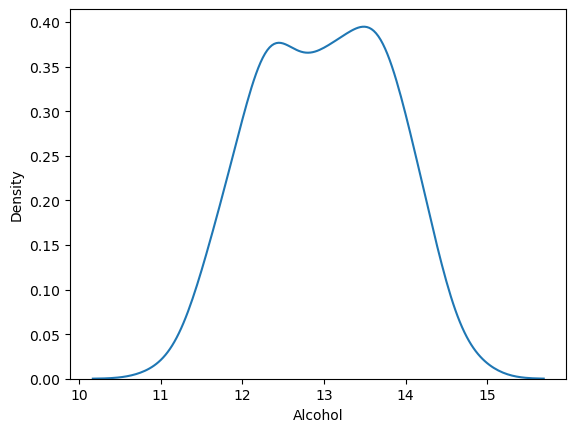

In [28]:
sns.kdeplot(data = df, x= 'Alcohol')

In [29]:
from sklearn.model_selection import train_test_split

In [31]:
X_train , X_test , y_train , y_test  = train_test_split(df.drop('ClassLabel', axis = 1),
                                                        df['ClassLabel'],
                                                        test_size = 0.3,
                                                        random_state = 0 )
X_train.shape ,X_test.shape

((123, 2), (54, 2))

In [34]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(X_train)

MinMaxScaler()

In [56]:
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [57]:
X_train_scaled = pd.DataFrame(X_train_scaled , columns = X_train.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled , columns = X_test.columns)
X_train_scaled

,Alcohol,MalicAcid
0,0.489247,0.144603
1,0.155914,0.093686
2,0.602151,0.690428
3,0.572581,0.545825
4,0.661290,0.156823
...,...,...
118,0.397849,0.171079
119,0.620968,0.010183
120,0.467742,0.517312
121,0.825269,0.230143


In [62]:
np.round(X_train.describe(), 1)

,Alcohol,MalicAcid
count,123.0,123.0
mean,13.0,2.3
std,0.8,1.2
min,11.0,0.9
25%,12.4,1.6
50%,13.0,1.8
75%,13.6,3.1
max,14.8,5.8


In [63]:
np.round(X_train_scaled.describe(), 1)

,Alcohol,MalicAcid
count,123.0,123.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.1
50%,0.5,0.2
75%,0.7,0.4
max,1.0,1.0


In [70]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# 1. Model create karo (yahaan KNN with k=5)
model = KNeighborsClassifier(n_neighbors=5)

# 2. Model ko training data pe fit karo
model.fit(X_train, y_train)

# 3. Test data pe predict karo
y_pred = model.predict(X_test_scaled)

# 4. Accuracy check karo
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


#bina scaling ke accuracy bhot low h 

Accuracy: 0.3888888888888889


In [69]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# 1. Model create karo (yahaan KNN with k=5)
model = KNeighborsClassifier(n_neighbors=5)

# 2. Model ko training data pe fit karo
model.fit(X_train_scaled, y_train)

# 3. Test data pe predict karo
y_pred = model.predict(X_test_scaled)

# 4. Accuracy check karo
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.7962962962962963
